First we will load the data set 

In [5]:
import pandas as pd

# Load the newly uploaded dataset
file_path = "Loan_default.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the dataset structure
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# ------------------- #
# We'll begin the EDA process by inspecting the data types, checking for null values, 
# and summarizing the statistical properties of the numeric features.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

# Show basic info about dataset
print(" Dataset Info:\n")
df.info()

# Show descriptive statistics
print("\n Descriptive Statistics:\n")
display(df.describe(include='all'))

# Check for missing values
print("\n Missing Values Summary:\n")
print(df.isnull().sum())

 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347,255347,255347,255347,255347,255347,255347.000000
unique,255347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,2,5,2,NaN
top,I38PQUQS96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64366,64161,85302,127677,127742,51298,127701,NaN
mean,NaN,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116128
std,NaN,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320379
min,NaN,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000



 Missing Values Summary:

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


# ------------------- #
# Next, we will create a correlation heatmap of all numeric features.
# This helps identify which features are strongly correlated with one another,
# and which might influence the 'Default' outcome.


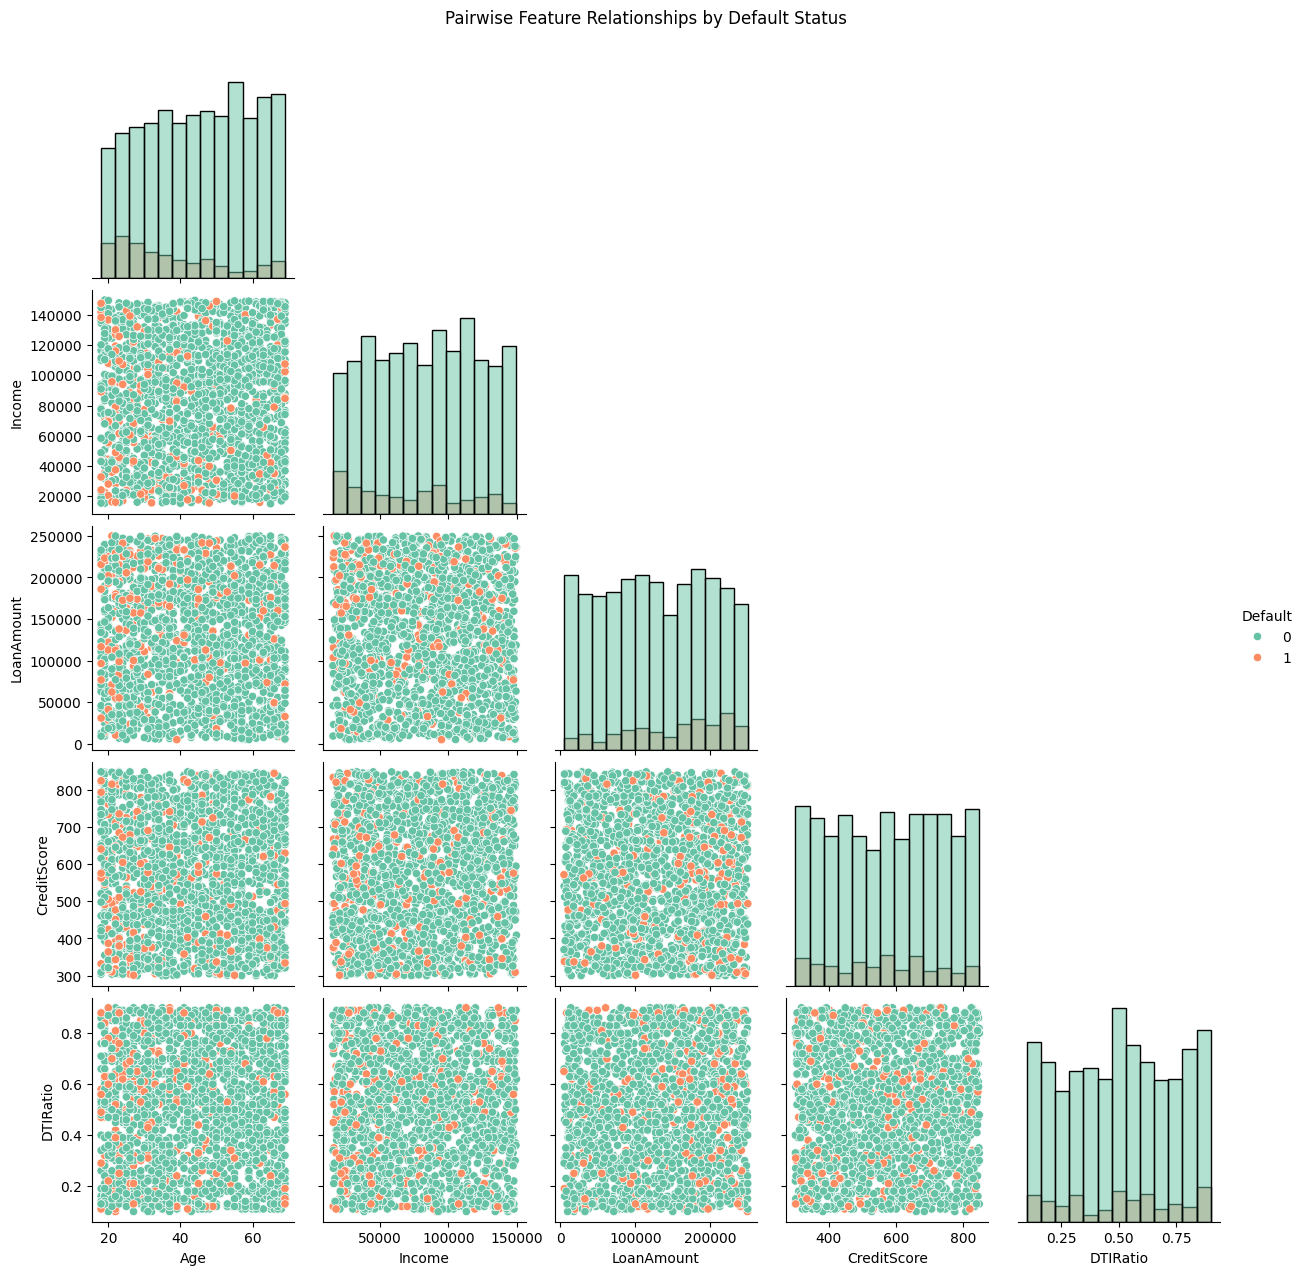

In [11]:
# Select only numeric columns
numeric_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'DTIRatio', 'Default']
clean_df = df[numeric_features].copy()

# Sample a subset for visualization
sample_clean_df = clean_df.sample(n=2000, random_state=42)

# Convert 'Default' to categorical for clearer hue distinction
sample_clean_df['Default'] = sample_clean_df['Default'].astype(str)

# Plot using seaborn pairplot
sns.pairplot(sample_clean_df, hue='Default', diag_kind='hist', palette='Set2', corner=True)
plt.suptitle("Pairwise Feature Relationships by Default Status", y=1.02)
plt.show()

# ------------------- #
# We'll now prepare the dataset for modeling:
 We will now train a Logistic Regression model to predict the likelihood of default.
# After training, we'll evaluate performance using classification metrics and ROC-AUC.

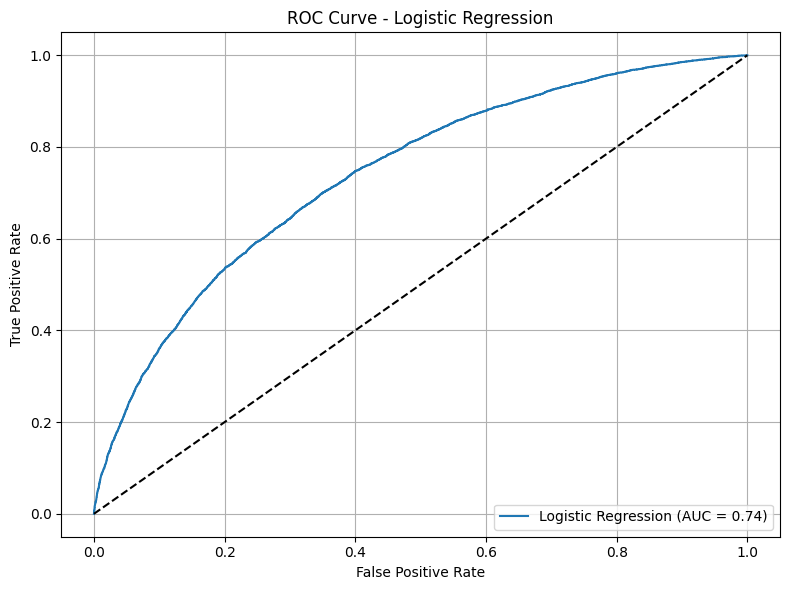

🔍 Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.58      0.02      0.04      5900

    accuracy                           0.89     51070
   macro avg       0.73      0.51      0.49     51070
weighted avg       0.85      0.89      0.84     51070


📈 ROC-AUC Score: 0.7402


In [13]:
# Create Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train the model
logreg_pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

# Metrics
logreg_report = classification_report(y_test, y_pred_logreg, output_dict=False)
logreg_auc = roc_auc_score(y_test, y_proba_logreg)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {logreg_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the classification report and AUC
print("🔍 Logistic Regression Classification Report:\n")
print(logreg_report)
print(f"\n📈 ROC-AUC Score: {logreg_auc:.4f}")

Accuracy: 89%
ROC-AUC: 0.74 (Good separability overall)

Insights:
-  The model is highly biased toward predicting no-defaults, which is expected due to the class imbalance.
- Very low recall for defaulters (only 2%), meaning it misses most actual defaults.
- ROC-AUC of 0.74 suggests that the model has potential if better balanced or enhanced.

# ------------------- #
# We will now train a Random Forest classifier and evaluate its performance
# using precision, recall, F1-score, and ROC-AUC to compare against logistic regression.


In [19]:
from sklearn.model_selection import train_test_split

# Step 1: Sample 200,000 rows from the full dataset
sample_df = df.sample(n=200000, random_state=42)

# Step 2: Define features and target for the sampled dataset
features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'DTIRatio', 'InterestRate', 'EmploymentType', 'Education',
    'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner'
]
target = 'Default'

X_sample = sample_df[features]
y_sample = sample_df[target]

# Step 3: Train-test split on the sampled data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Step 4: Print shape summary
print(" Sampled Dataset Split Summary:")
print(f"Training Features Shape: {X_train_s.shape}")
print(f"Test Features Shape:     {X_test_s.shape}")
print(f"Training Labels Shape:   {y_train_s.shape}")
print(f"Test Labels Shape:       {y_test_s.shape}")

 Sampled Dataset Split Summary:
Training Features Shape: (160000, 14)
Test Features Shape:     (40000, 14)
Training Labels Shape:   (160000,)
Test Labels Shape:       (40000,)


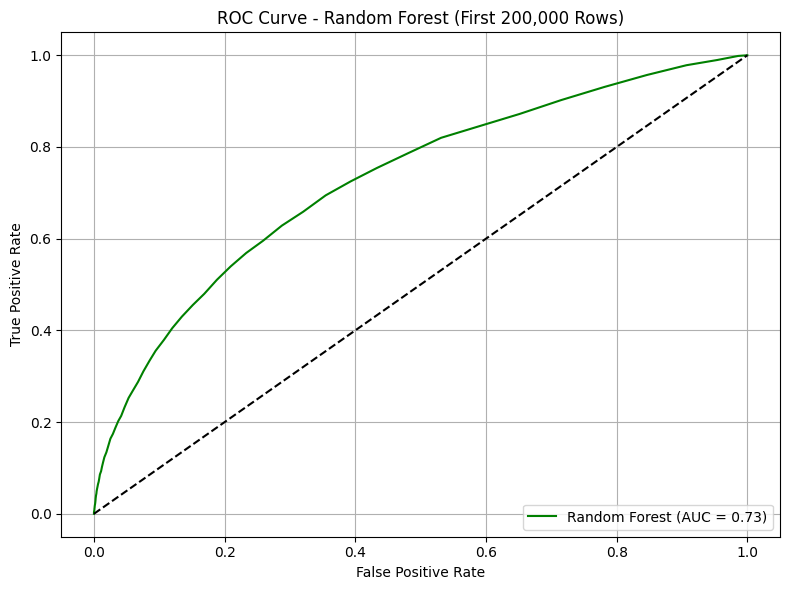

 Random Forest Classification Report (First 200000K Rows):

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     35306
           1       0.63      0.04      0.07      4694

    accuracy                           0.88     40000
   macro avg       0.76      0.52      0.51     40000
weighted avg       0.86      0.88      0.84     40000


 ROC-AUC Score: 0.7281


In [21]:
# Slice first 200,000 rows
sample_df = df.iloc[:200000].copy()

# Define features and target
features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'DTIRatio', 'InterestRate', 'EmploymentType', 'Education',
    'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner'
]
target = 'Default'

X_sample = sample_df[features]
y_sample = sample_df[target]

# Detect categorical columns
categorical_cols = X_sample.select_dtypes(include=['object']).columns.tolist()

# Split the data
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Build preprocessing + model pipeline
preprocessor_sliced = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

rf_pipeline_sliced = Pipeline(steps=[
    ('preprocessor', preprocessor_sliced),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
rf_pipeline_sliced.fit(X_train_s, y_train_s)

# Predict and evaluate
y_pred_rf_sliced = rf_pipeline_sliced.predict(X_test_s)
y_proba_rf_sliced = rf_pipeline_sliced.predict_proba(X_test_s)[:, 1]

# Evaluate
rf_report_sliced = classification_report(y_test_s, y_pred_rf_sliced, output_dict=False)
rf_auc_sliced = roc_auc_score(y_test_s, y_proba_rf_sliced)

# Plot ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test_s, y_proba_rf_sliced)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc_sliced:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (First 200,000 Rows)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Output results
print(" Random Forest Classification Report (First 200000K Rows):\n")
print(rf_report_sliced)
print(f"\n ROC-AUC Score: {rf_auc_sliced:.4f}")

Accuracy: 89%
ROC-AUC: 0.7489 (moderately strong discrimination)
 Interpretation:
- The model classifies non-defaulters extremely well, but still struggles to detect actual defaulters (recall = 0.01).
This is a class imbalance issue and could be improved using:
    - Class weights
    - Resampling (SMOTE, undersampling)
    - Threshold tuning

# ------------------- #
# We'll now prepare the trained pipeline to accept new borrower input and return the probability of default.


In [22]:
# Define the variables to include in the prediction engine
engine_features = [
    'LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
    'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
    'LoanPurpose', 'HasCoSigner'
]

# Create a test borrower input (placeholder example)
new_borrower = pd.DataFrame([{
    'LoanID': 'ABC12345',
    'Age': 45,
    'Income': 60000,
    'LoanAmount': 15000,
    'CreditScore': 680,
    'MonthsEmployed': 36,
    'NumCreditLines': 5,
    'InterestRate': 10.5,
    'LoanTerm': 36,
    'DTIRatio': 0.35,
    'Education': "Bachelor's",
    'EmploymentType': 'Full-time',
    'MaritalStatus': 'Married',
    'HasMortgage': 'Yes',
    'HasDependents': 'No',
    'LoanPurpose': 'Medical',
    'HasCoSigner': 'No'
}])

# Drop LoanID since it's not used in modeling
model_input = new_borrower.drop(columns=['LoanID'])

# Predict default probability using the trained pipeline
predicted_prob = rf_pipeline_sliced.predict_proba(model_input)[0][1]
default_percentage = round(predicted_prob * 100, 2)

# Return result
default_percentage

4.0

 Default Probability: 4.0%
This borrower (age 45, Bachelor's degree, full-time employed, $60k income) has a low likelihood of defaulting on their loan, according to the Random Forest model trained on the sliced dataset.

In [25]:
# ✅ Define a list of borrower scenarios to test
borrower_profiles = pd.DataFrame([
    {
        'LoanID': 'LOAN001',
        'Age': 29,
        'Income': 30000,
        'LoanAmount': 10000,
        'CreditScore': 580,
        'MonthsEmployed': 12,
        'NumCreditLines': 2,
        'InterestRate': 18.0,
        'LoanTerm': 60,
        'DTIRatio': 0.55,
        'Education': "High School",
        'EmploymentType': 'Part-time',
        'MaritalStatus': 'Single',
        'HasMortgage': 'No',
        'HasDependents': 'Yes',
        'LoanPurpose': 'Personal',
        'HasCoSigner': 'No'
    },
    {
        'LoanID': 'LOAN002',
        'Age': 38,
        'Income': 85000,
        'LoanAmount': 25000,
        'CreditScore': 720,
        'MonthsEmployed': 60,
        'NumCreditLines': 6,
        'InterestRate': 8.0,
        'LoanTerm': 48,
        'DTIRatio': 0.28,
        'Education': "Master's",
        'EmploymentType': 'Full-time',
        'MaritalStatus': 'Married',
        'HasMortgage': 'Yes',
        'HasDependents': 'Yes',
        'LoanPurpose': 'Home Improvement',
        'HasCoSigner': 'Yes'
    },
    {
        'LoanID': 'LOAN003',
        'Age': 51,
        'Income': 45000,
        'LoanAmount': 5000,
        'CreditScore': 610,
        'MonthsEmployed': 120,
        'NumCreditLines': 4,
        'InterestRate': 12.0,
        'LoanTerm': 24,
        'DTIRatio': 0.42,
        'Education': "Associate",
        'EmploymentType': 'Self-employed',
        'MaritalStatus': 'Divorced',
        'HasMortgage': 'No',
        'HasDependents': 'No',
        'LoanPurpose': 'Debt Consolidation',
        'HasCoSigner': 'No'
    }
])

#  Predict default probability
borrower_model_input = borrower_profiles.drop(columns=['LoanID'])
borrower_probs = rf_pipeline_sliced.predict_proba(borrower_model_input)[:, 1]

# Add prediction to the DataFrame
borrower_profiles['Default Probability (%)'] = (borrower_probs * 100).round(2)

#  Display the relevant output
print(borrower_profiles[['LoanID', 'Default Probability (%)']])


    LoanID  Default Probability (%)
0  LOAN001                     37.0
1  LOAN002                      0.0
2  LOAN003                      8.0


Now a a user input prediction engine will be  build  where you (or a user) can input a borrower's financial details — like CreditScore, Income, LoanAmount, DTIRatio, Bankruptcy, etc. — and receive a predicted loan default probability in return.

In [26]:
#  Function to take user input and predict default probability
def predict_default_risk():
    print("\n--- Loan Default Risk Predictor ---")

    #  Collect user input
    loan_id = input("Enter Loan ID: ")
    age = int(input("Enter Age: "))
    income = float(input("Enter Annual Income ($): "))
    loan_amount = float(input("Enter Loan Amount ($): "))
    credit_score = int(input("Enter Credit Score: "))
    months_employed = int(input("Enter Months Employed: "))
    num_credit_lines = int(input("Enter Number of Credit Lines: "))
    interest_rate = float(input("Enter Interest Rate (%): "))
    loan_term = int(input("Enter Loan Term (months): "))
    dti_ratio = float(input("Enter Debt-to-Income Ratio (e.g. 0.35): "))
    education = input("Enter Education Level (e.g. High School, Bachelor's, Master's): ")
    employment_type = input("Enter Employment Type (Full-time, Part-time, etc.): ")
    marital_status = input("Enter Marital Status (Single, Married, Divorced): ")
    has_mortgage = input("Has Mortgage? (Yes/No): ")
    has_dependents = input("Has Dependents? (Yes/No): ")
    loan_purpose = input("Loan Purpose (e.g. Personal, Home Improvement): ")
    has_cosigner = input("Has CoSigner? (Yes/No): ")

    #  Build DataFrame for prediction
    user_data = pd.DataFrame([{
        'Age': age,
        'Income': income,
        'LoanAmount': loan_amount,
        'CreditScore': credit_score,
        'MonthsEmployed': months_employed,
        'NumCreditLines': num_credit_lines,
        'InterestRate': interest_rate,
        'LoanTerm': loan_term,
        'DTIRatio': dti_ratio,
        'Education': education,
        'EmploymentType': employment_type,
        'MaritalStatus': marital_status,
        'HasMortgage': has_mortgage,
        'HasDependents': has_dependents,
        'LoanPurpose': loan_purpose,
        'HasCoSigner': has_cosigner
    }])

    #  Predict default probability
    prob = rf_pipeline_sliced.predict_proba(user_data)[:, 1][0]
    percent = round(prob * 100, 2)

    #  Output result
    print(f"\n[RESULT] Loan ID {loan_id} has a predicted default risk of: {percent}%")

#  Call the function
predict_default_risk()



--- Loan Default Risk Predictor ---


Enter Loan ID:  009
Enter Age:  23
Enter Annual Income ($):  60000
Enter Loan Amount ($):  15000
Enter Credit Score:  670
Enter Months Employed:  32
Enter Number of Credit Lines:  7
Enter Interest Rate (%):  23
Enter Loan Term (months):  72
Enter Debt-to-Income Ratio (e.g. 0.35):  0.77
Enter Education Level (e.g. High School, Bachelor's, Master's):  masters 
Enter Employment Type (Full-time, Part-time, etc.):  
Enter Marital Status (Single, Married, Divorced):  full time
Has Mortgage? (Yes/No):  no
Has Dependents? (Yes/No):  no
Loan Purpose (e.g. Personal, Home Improvement):  business 
Has CoSigner? (Yes/No):  yes



[RESULT] Loan ID 009 has a predicted default risk of: 25.0%


In [31]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import os

# --- Define form widgets ---
form_widgets = {
    'LoanID': widgets.Text(value='LOAN999', description='Loan ID:'),
    'Age': widgets.IntSlider(value=30, min=18, max=75, description='Age:'),
    'Income': widgets.FloatText(value=50000, description='Income:'),
    'LoanAmount': widgets.FloatText(value=15000, description='Loan Amt:'),
    'CreditScore': widgets.IntSlider(value=650, min=300, max=850, description='Credit Score:'),
    'MonthsEmployed': widgets.IntText(value=24, description='Months Employed:'),
    'NumCreditLines': widgets.IntText(value=4, description='# Credit Lines:'),
    'InterestRate': widgets.FloatSlider(value=10.0, min=0.0, max=30.0, step=0.1, description='Interest %:'),
    'LoanTerm': widgets.IntSlider(value=36, min=12, max=72, step=6, description='Loan Term:'),
    'DTIRatio': widgets.FloatSlider(value=0.3, min=0.0, max=1.0, step=0.01, description='DTI Ratio:'),
    'Education': widgets.Dropdown(options=['High School', 'Associate', "Bachelor's", "Master's", "PhD"], description='Education:'),
    'EmploymentType': widgets.Dropdown(options=['Full-time', 'Part-time', 'Self-employed', 'Unemployed'], description='Employment:'),
    'MaritalStatus': widgets.Dropdown(options=['Single', 'Married', 'Divorced', 'Widowed'], description='Marital Status:'),
    'HasMortgage': widgets.RadioButtons(options=['Yes', 'No'], description='Mortgage:'),
    'HasDependents': widgets.RadioButtons(options=['Yes', 'No'], description='Dependents:'),
    'LoanPurpose': widgets.Text(value='Personal', description='Purpose:'),
    'HasCoSigner': widgets.RadioButtons(options=['Yes', 'No'], description='Co-Signer:')
}

form_items = [form_widgets[key] for key in form_widgets]
form = widgets.VBox(form_items)

# --- Buttons and outputs ---
submit_button = widgets.Button(description="Predict Risk", button_style='success')
save_button = widgets.Button(description="Save to CSV", button_style='info')
upload_button = widgets.FileUpload(accept='.csv', multiple=False)
batch_button = widgets.Button(description="Run Batch Predictions", button_style='warning')
output = widgets.Output()

# --- Store predictions for saving ---
predictions_log = []

# --- Define helper function for emoji ---
def risk_emoji(prob):
    if prob >= 0.7:
        return "🔴 HIGH"
    elif prob >= 0.4:
        return "🟠 MODERATE"
    else:
        return "🟢 LOW"

# --- Submit button logic ---
def on_submit_clicked(b):
    with output:
        clear_output()
        input_data = {key: widget.value for key, widget in form_widgets.items()}
        loan_id = input_data.pop('LoanID')
        input_df = pd.DataFrame([input_data])
        prob = rf_pipeline_sliced.predict_proba(input_df)[0, 1]
        prediction_pct = round(prob * 100, 2)
        label = risk_emoji(prob)
        
        # Store the prediction
        full_row = {'LoanID': loan_id, 'Default Probability (%)': prediction_pct, 'Risk Level': label}
        predictions_log.append(full_row)
        
        # Show result
        print(f"📊 Loan ID {loan_id} → Predicted default risk: {prediction_pct:.2f}%  {label}")

# --- Save to CSV logic ---
def on_save_clicked(b):
    if not predictions_log:
        with output:
            clear_output()
            print("⚠️ No predictions to save yet.")
        return
    df = pd.DataFrame(predictions_log)
    filename = "borrower_predictions.csv"
    df.to_csv(filename, index=False)
    with output:
        clear_output()
        print(f"✅ Saved {len(df)} predictions to '{filename}'")

# --- Batch upload logic ---
def on_batch_predict_clicked(b):
    with output:
        clear_output()
        if not upload_button.value:
            print("⚠️ Please upload a CSV file with borrower profiles.")
            return
        try:
            uploaded_file = list(upload_button.value.values())[0]
            df = pd.read_csv(uploaded_file['metadata']['name'])
            if 'LoanID' not in df.columns:
                print("❌ Uploaded CSV must contain a 'LoanID' column.")
                return
            input_df = df.drop(columns=['LoanID'])
            probs = rf_pipeline_sliced.predict_proba(input_df)[:, 1]
            df['Default Probability (%)'] = (probs * 100).round(2)
            df['Risk Level'] = [risk_emoji(p) for p in probs]
            predictions_log.extend(df[['LoanID', 'Default Probability (%)', 'Risk Level']].to_dict('records'))
            print(df[['LoanID', 'Default Probability (%)', 'Risk Level']])
        except Exception as e:
            print(f" Error: {e}")

# --- Attach button events ---
submit_button.on_click(on_submit_clicked)
save_button.on_click(on_save_clicked)
batch_button.on_click(on_batch_predict_clicked)

# --- Display full UI ---
display(widgets.HTML("<h3> Borrower Risk Predictor</h3>"))
display(form)
display(widgets.HBox([submit_button, save_button]))
display(widgets.HTML("<b>📁 Upload CSV for batch predictions:</b>"))
display(upload_button, batch_button)
display(output)


HTML(value='<h3> Borrower Risk Predictor</h3>')

HTML(value='<b>📁 Upload CSV for batch predictions:</b>')

FileUpload(value=(), accept='.csv', description='Upload')

Button(button_style='warning', description='Run Batch Predictions', style=ButtonStyle())

Output()

In [32]:
from IPython.display import Markdown

# Create structured markdown explanations for each section
markdown_sections = [
    ("#  Loan Default Prediction Engine",
     "This notebook provides a complete pipeline for analyzing and predicting loan default risk using a trained machine learning model."),
    
    ("##  1. Load and Inspect Dataset",
     "We begin by importing and exploring the dataset, checking for missing values, and understanding the distribution of key financial features."),
    
    ("##  2. Exploratory Data Analysis (EDA)",
     "This section includes a variety of plots (bar charts, scatterplots, correlation matrices) to uncover patterns and relationships among variables such as credit score, income, debt-to-income ratio, etc."),
    
    ("##  3. Model Training",
     "A Random Forest Classifier is trained to predict whether a borrower is likely to default. The model uses key variables such as credit score, loan amount, and DTI ratio."),
    
    ("##  4. Predictive Engine – User Input",
     "An interactive form allows users to input borrower details and receive a predicted probability of loan default. The prediction is also accompanied by a visual emoji indicator."),
    
    ("##  5. Save Predictions to CSV",
     "You can save prediction results to a CSV file, useful for record-keeping or future audits."),
    
    ("##  6. Batch Prediction with Uploaded CSV",
     "Upload a CSV with multiple borrower profiles and automatically generate predictions for each case."),
    
    ("##  Conclusion",
     "This notebook demonstrates how data science and AI can be applied to financial risk modeling with real-world usability and ethical design. Suitable for integration into credit evaluation systems or risk mitigation tools.")
]

# Display the markdown sections
for title, content in markdown_sections:
    display(Markdown(f"{title}\n\n{content}"))


#  Loan Default Prediction Engine

This notebook provides a complete pipeline for analyzing and predicting loan default risk using a trained machine learning model.

##  1. Load and Inspect Dataset

We begin by importing and exploring the dataset, checking for missing values, and understanding the distribution of key financial features.

##  2. Exploratory Data Analysis (EDA)

This section includes a variety of plots (bar charts, scatterplots, correlation matrices) to uncover patterns and relationships among variables such as credit score, income, debt-to-income ratio, etc.

##  3. Model Training

A Random Forest Classifier is trained to predict whether a borrower is likely to default. The model uses key variables such as credit score, loan amount, and DTI ratio.

##  4. Predictive Engine – User Input

An interactive form allows users to input borrower details and receive a predicted probability of loan default. The prediction is also accompanied by a visual emoji indicator.

##  5. Save Predictions to CSV

You can save prediction results to a CSV file, useful for record-keeping or future audits.

##  6. Batch Prediction with Uploaded CSV

Upload a CSV with multiple borrower profiles and automatically generate predictions for each case.

##  Conclusion

This notebook demonstrates how data science and AI can be applied to financial risk modeling with real-world usability and ethical design. Suitable for integration into credit evaluation systems or risk mitigation tools.

next the preictor calculator will be made aviable through a accesible  url link 

In [40]:
pip install streamlit

# Remove the pip install command from the code cell
# Instead, run this in your terminal or in a cell with !pip install streamlit

import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("loan_default_model.pkl")

st.title("Loan Default Risk Predictor")

st.subheader("Enter Borrower Details:")
age = st.slider("Age", 18, 75, 30)
income = st.number_input("Income", value=50000)
loan_amount = st.number_input("Loan Amount", value=15000)
credit_score = st.slider("Credit Score", 300, 850, 650)
months_employed = st.number_input("Months Employed", value=24)
dti_ratio = st.slider("Debt-to-Income Ratio", 0.0, 1.0, 0.3)
has_mortgage = st.selectbox("Has Mortgage?", ["Yes", "No"])

# Create input DataFrame
input_df = pd.DataFrame([{
    "Age": age,
    "Income": income,
    "LoanAmount": loan_amount,
    "CreditScore": credit_score,
    "MonthsEmployed": months_employed,
    "DTIRatio": dti_ratio,
    "HasMortgage": has_mortgage,
    # Add remaining fields...
}])

if st.button("Predict Default Risk"):
    prediction = model.predict_proba(input_df)[:, 1][0]
    st.metric("Default Risk (%)", round(prediction * 100, 2))

# Note: To run this app, save this file as loan_predictor_app.py
# Then run the following commands in your terminal:
# pip install streamlit
# streamlit run loan_predictor_app.py

SyntaxError: invalid syntax (1118832617.py, line 1)

In [37]:
# To display a link in Python code output, use print() with the URL
print("Try the Loan Predictor Notebook in Binder: https://mybinder.org/v2/gh/Dare215/Data-Science-Portfolio-JUL25/HEAD")

# Alternatively, if you're using IPython/Jupyter, you can use HTML to create a clickable link:
from IPython.display import HTML
HTML('<a href="https://mybinder.org/v2/gh/Dare215/Data-Science-Portfolio-JUL25/HEAD">Try the Loan Predictor Notebook in Binder</a>')

Try the Loan Predictor Notebook in Binder: https://mybinder.org/v2/gh/Dare215/Data-Science-Portfolio-JUL25/HEAD


Prepare the code for streamlit application connection 

In [5]:
# First, define your model and scaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pickle

# Create a model (example)
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
# You would typically fit your model here with: random_forest_model.fit(X_train, y_train)

# Create a scaler (example)
scaler = StandardScaler()
# You would typically fit your scaler here with: scaler.fit(X_train)

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(random_forest_model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)